In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [4]:
# Load and preprocess an image
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5])
])
image = Image.open("/content/sample.jpg").convert("RGB")  # replace with your image
x_start = transform(image).unsqueeze(0)  # shape: [1, 3, 64, 64]

print(image.size)
image.show()  # Make sure it displays normally

(857, 675)


In [5]:
# Forward process: add noise over time
def forward_diffusion(x, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x)
    alpha = 1 - 0.02 * t  # simple linear schedule
    return (alpha**0.5) * x + ((1 - alpha)**0.5) * noise


In [6]:
# Dummy reverse model (in real use, this is a trained U-Net)
class DummyUNet(nn.Module):
    def forward(self, x, t):
        return torch.randn_like(x) * 0.5  # pretend it predicts noise

In [7]:
model = DummyUNet()

In [8]:
# Simulate the reverse denoising process
def reverse_diffusion(x_noisy, steps=10):
    x = x_noisy
    for t in reversed(range(steps)):
        predicted_noise = model(x, t)
        alpha = 1 - 0.02 * t
        x = (x - ((1 - alpha) ** 0.5) * predicted_noise) / (alpha ** 0.5)
    return x

In [9]:
# Forward: add noise
t = 10  # max timestep
x_noisy = forward_diffusion(x_start, t)

# Reverse: denoise
x_denoised = reverse_diffusion(x_noisy, steps=t)

In [10]:
# Visualize
def show_tensor_image(tensor, title):
    img = tensor.squeeze(0).detach().cpu().numpy()
    img = (img * 0.5 + 0.5).clip(0, 1).transpose(1, 2, 0)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

In [11]:
print("x_start:", x_start.shape)
print("x_noisy:", x_noisy.shape)
print("x_denoised:", x_denoised.shape)

x_start: torch.Size([1, 3, 64, 64])
x_noisy: torch.Size([1, 3, 64, 64])
x_denoised: torch.Size([1, 3, 64, 64])


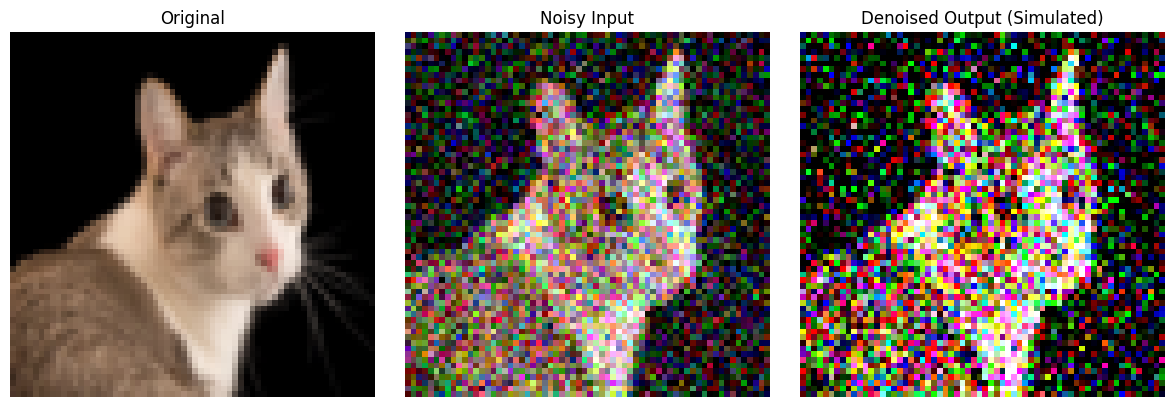

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); show_tensor_image(x_start, "Original")
plt.subplot(1, 3, 2); show_tensor_image(x_noisy, "Noisy Input")
plt.subplot(1, 3, 3); show_tensor_image(x_denoised, "Denoised Output (Simulated)")
plt.tight_layout(); plt.show()